# Task 1: Data Exploration and Enrichment

## Objective
Understand the starter dataset and enrich it with additional data useful for forecasting Access and Usage.

### Deliverables:
- Comprehensive exploration of dataset structure
- Data quality assessment
- Enrichment with additional observations and events
- Documentation of all additions
- Export figures and summaries for final report

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths
DATA_RAW_PATH = '../data/raw/ethiopia_fi_unified_data.csv'
REF_CODES_PATH = '../data/raw/reference_codes.csv'
REPORTDATA_PATH = '../data/reportdata'
FIGURES_PATH = os.path.join(REPORTDATA_PATH, 'figures')
SUMMARIES_PATH = os.path.join(REPORTDATA_PATH, 'summaries')

# Helper function to save figures
def save_fig(fig_name, dpi=300, bbox_inches='tight'):
    """Save figure to reportdata/figures directory"""
    filepath = os.path.join(FIGURES_PATH, f'{fig_name}.png')
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    print(f"✓ Saved: {fig_name}.png")

# Helper function to save summaries
def save_summary(df, filename):
    """Save summary dataframe to reportdata/summaries directory"""
    filepath = os.path.join(SUMMARIES_PATH, filename)
    df.to_csv(filepath, index=False)
    print(f"✓ Saved: {filename}")

## 1. Load and Understand the Schema

In [2]:
# Load datasets
df = pd.read_csv(DATA_RAW_PATH)
ref_codes = pd.read_csv(REF_CODES_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (43, 34)

Columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

First few rows:


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [17]:
# Examine data types and missing values
info_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values
})

save_summary(info_summary, 'dataset_info.csv')
info_summary

✓ Saved: dataset_info.csv


,Column,Data Type,Non-Null Count,Null Count,Null %
0,record_id,object,43,0,0.00
1,record_type,object,43,0,0.00
2,category,object,10,33,76.74
3,pillar,object,33,10,23.26
4,indicator,object,43,0,0.00
5,indicator_code,object,43,0,0.00
6,indicator_direction,object,33,10,23.26
7,value_numeric,float64,33,10,23.26
8,value_text,object,10,33,76.74
9,value_type,object,43,0,0.00


In [3]:
# Understand reference codes
print("Reference Codes Structure:")
print(ref_codes.head(10))
print(f"\nTotal reference codes: {len(ref_codes)}")

Reference Codes Structure:
         field            code  \
0  record_type     observation   
1  record_type           event   
2  record_type     impact_link   
3  record_type          target   
4  record_type        baseline   
5  record_type        forecast   
6     category  product_launch   
7     category    market_entry   
8     category     market_exit   
9     category          policy   

                                         description applies_to  
0                Actual measured value from a source        All  
1            Policy launch market event or milestone        All  
2  Relationship between event and indicator (link...        All  
3                     Policy target or official goal        All  
4                      Starting point for comparison        All  
5                             Predicted future value        All  
6                  New product or service introduced      event  
7                       New competitor enters market      event  
8   

## 2. Explore Data by Record Type

✓ Saved: record_type_counts.csv


/tmp/ipykernel_4368/571125936.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=record_type_counts, x='Record Type', y='Count', palette='viridis')


✓ Saved: 01_record_type_distribution.png


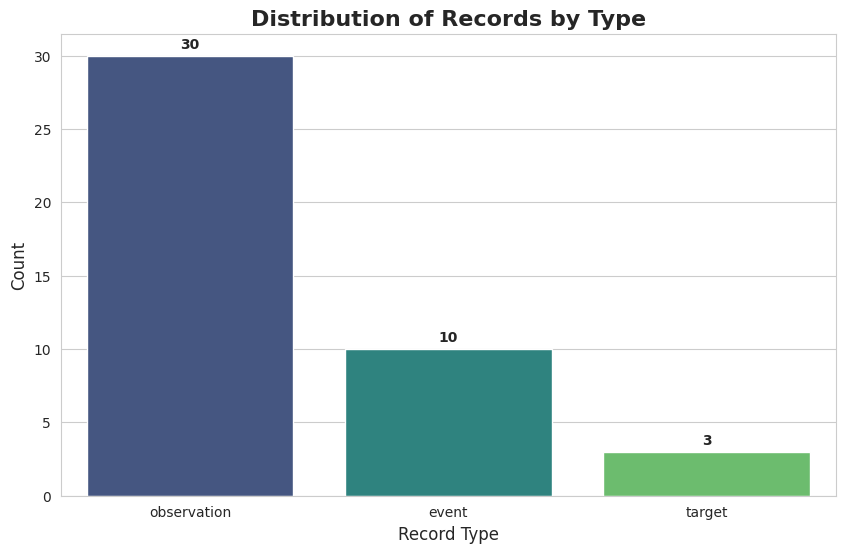

,Record Type,Count
0,observation,30
1,event,10
2,target,3


In [4]:
# Count records by type
record_type_counts = df['record_type'].value_counts().reset_index()
record_type_counts.columns = ['Record Type', 'Count']

save_summary(record_type_counts, 'record_type_counts.csv')

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=record_type_counts, x='Record Type', y='Count', palette='viridis')
plt.title('Distribution of Records by Type', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Record Type', fontsize=12)
for i, v in enumerate(record_type_counts['Count']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
save_fig('01_record_type_distribution')
plt.show()

record_type_counts

In [5]:
# Examine each record type separately
print("=" * 80)
print("OBSERVATIONS")
print("=" * 80)
observations = df[df['record_type'] == 'observation'].copy()
print(f"Total observations: {len(observations)}")
print(f"\nColumns with data:")
print(observations.notna().sum())

print("\n" + "=" * 80)
print("EVENTS")
print("=" * 80)
events = df[df['record_type'] == 'event'].copy()
print(f"Total events: {len(events)}")
print(f"\nEvent categories:")
print(events['category'].value_counts())

print("\n" + "=" * 80)
print("IMPACT LINKS")
print("=" * 80)
impact_links = df[df['record_type'] == 'impact_link'].copy()
print(f"Total impact links: {len(impact_links)}")

print("\n" + "=" * 80)
print("TARGETS")
print("=" * 80)
targets = df[df['record_type'] == 'target'].copy()
print(f"Total targets: {len(targets)}")
if len(targets) > 0:
    # Show relevant columns - using fiscal_year instead of target_year
    target_cols = ['pillar', 'indicator', 'value_numeric', 'fiscal_year']
    available_cols = [col for col in target_cols if col in targets.columns]
    print(targets[available_cols].dropna(how='all'))

OBSERVATIONS
Total observations: 30

Columns with data:
record_id              30
record_type            30
category                0
pillar                 30
indicator              30
indicator_code         30
indicator_direction    30
value_numeric          30
value_text              0
value_type             30
unit                   30
observation_date       30
period_start            9
period_end              9
fiscal_year            30
gender                 30
location               30
region                  0
source_name            30
source_type            30
source_url             25
confidence             30
related_indicator       0
relationship_type       0
impact_direction        0
impact_magnitude        0
impact_estimate         0
lag_months              0
evidence_basis          0
comparable_country     30
collected_by           30
collection_date        10
original_text          20
notes                   0
dtype: int64

EVENTS
Total events: 10

Event categories:
cat

## 3. Temporal Coverage Analysis

Observation Temporal Coverage:
Earliest: 2014-12-31 00:00:00
Latest: 2025-12-31 00:00:00

Observations by year:
observation_date
2014     1
2017     1
2021     5
2023     1
2024    11
2025    11
Name: count, dtype: int64
✓ Saved: 02_temporal_coverage.png


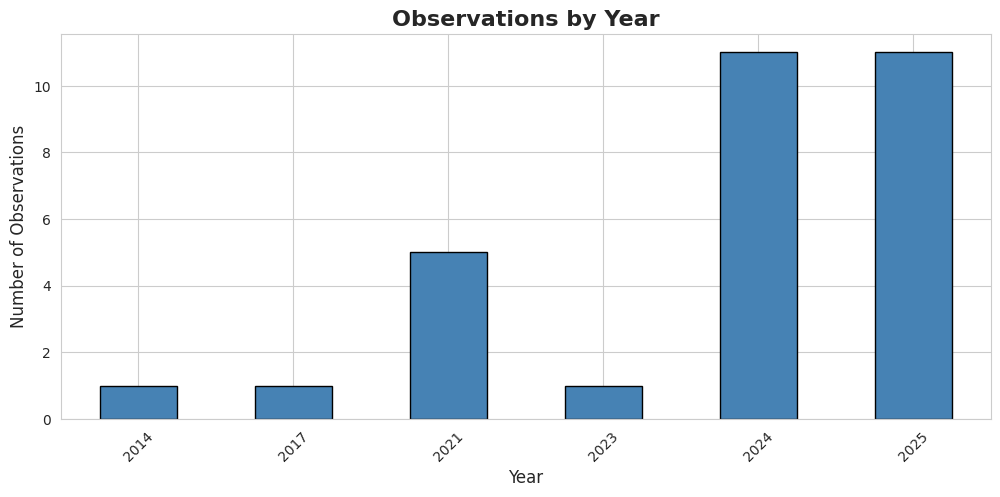

In [6]:
# Parse dates
observations['observation_date'] = pd.to_datetime(observations['observation_date'], errors='coerce')
# Events use observation_date column, not event_date
if 'observation_date' in events.columns:
    events['observation_date'] = pd.to_datetime(events['observation_date'], errors='coerce')

# Temporal range of observations
print("Observation Temporal Coverage:")
print(f"Earliest: {observations['observation_date'].min()}")
print(f"Latest: {observations['observation_date'].max()}")
print(f"\nObservations by year:")
obs_by_year = observations['observation_date'].dt.year.value_counts().sort_index()
print(obs_by_year)

# Visualize temporal coverage
plt.figure(figsize=(12, 5))
obs_by_year.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Observations by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45)
save_fig('02_temporal_coverage')
plt.show()

## 4. Indicator Analysis

In [7]:
# List all unique indicators
indicator_summary = observations.groupby(['pillar', 'indicator', 'indicator_code']).agg({
    'value_numeric': 'count',
    'observation_date': ['min', 'max']
}).reset_index()

indicator_summary.columns = ['Pillar', 'Indicator', 'Code', 'Count', 'First Date', 'Last Date']
indicator_summary = indicator_summary.sort_values('Count', ascending=False)

save_summary(indicator_summary, 'indicator_coverage.csv')

print("\nIndicator Coverage Summary:")
indicator_summary

✓ Saved: indicator_coverage.csv

Indicator Coverage Summary:


,Pillar,Indicator,Code,Count,First Date,Last Date
1,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,6,2014-12-31,2024-11-29
2,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,3,2024-08-15,2025-05-15
0,ACCESS,4G Population Coverage,ACC_4G_COV,2,2023-06-30,2025-06-30
3,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,2,2021-12-31,2024-11-29
6,GENDER,Account Ownership Gender Gap,GEN_GAP_ACC,2,2021-12-31,2024-11-29
14,USAGE,P2P Transaction Count,USG_P2P_COUNT,2,2024-07-07,2025-07-07
4,ACCESS,Mobile Subscription Penetration,ACC_MOBILE_PEN,1,2025-12-31,2025-12-31
7,GENDER,Female Mobile Money Account Share,GEN_MM_SHARE,1,2024-12-31,2024-12-31
8,GENDER,Mobile Phone Gender Gap,GEN_GAP_MOBILE,1,2024-12-31,2024-12-31
9,USAGE,ATM Transaction Count,USG_ATM_COUNT,1,2025-07-07,2025-07-07


/tmp/ipykernel_7765/173047168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pillar_counts, x='Pillar', y='Count', palette='Set2')


✓ Saved: 03_observations_by_pillar.png


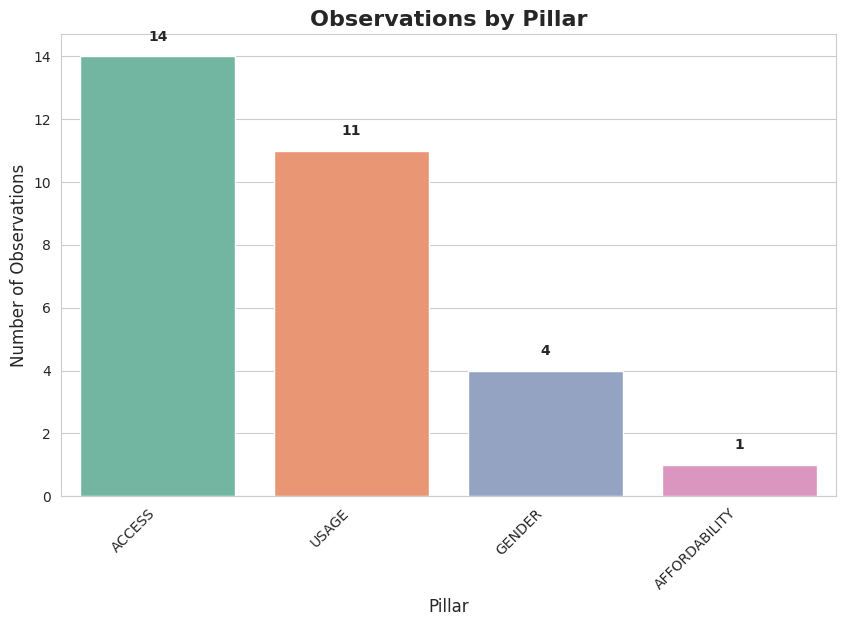

In [25]:
# Visualize indicator coverage by pillar
pillar_counts = observations['pillar'].value_counts().reset_index()
pillar_counts.columns = ['Pillar', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=pillar_counts, x='Pillar', y='Count', palette='Set2')
plt.title('Observations by Pillar', fontsize=16, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xlabel('Pillar', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(pillar_counts['Count']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
save_fig('03_observations_by_pillar')
plt.show()

## 5. Data Quality Assessment

✓ Saved: confidence_distribution.csv


/tmp/ipykernel_4368/1416787081.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=confidence_dist, x='Confidence Level', y='Count', palette='RdYlGn')


✓ Saved: 04_confidence_distribution.png


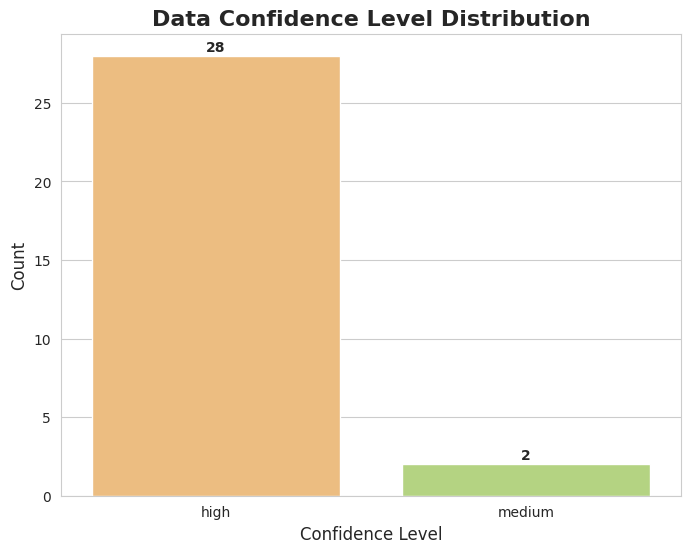

,Confidence Level,Count
0,high,28
1,medium,2


In [8]:
# Confidence level distribution
confidence_dist = observations['confidence'].value_counts().reset_index()
confidence_dist.columns = ['Confidence Level', 'Count']

save_summary(confidence_dist, 'confidence_distribution.csv')

plt.figure(figsize=(8, 6))
sns.barplot(data=confidence_dist, x='Confidence Level', y='Count', palette='RdYlGn')
plt.title('Data Confidence Level Distribution', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Confidence Level', fontsize=12)
for i, v in enumerate(confidence_dist['Count']):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
save_fig('04_confidence_distribution')
plt.show()

confidence_dist

✓ Saved: source_type_distribution.csv


/tmp/ipykernel_7765/373524446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_type_dist, x='Source Type', y='Count', palette='muted')


✓ Saved: 05_source_type_distribution.png


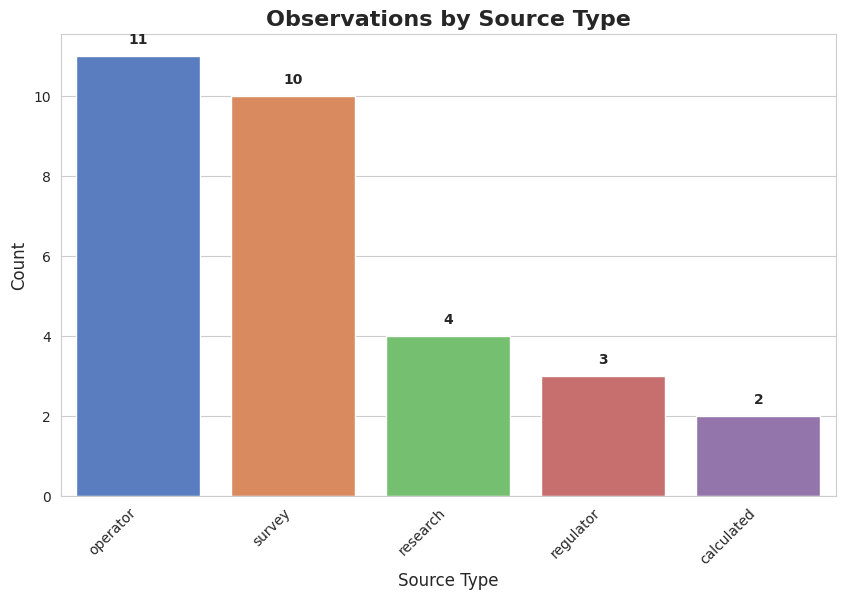

,Source Type,Count
0,operator,11
1,survey,10
2,research,4
3,regulator,3
4,calculated,2


In [27]:
# Source type analysis
source_type_dist = observations['source_type'].value_counts().reset_index()
source_type_dist.columns = ['Source Type', 'Count']

save_summary(source_type_dist, 'source_type_distribution.csv')

plt.figure(figsize=(10, 6))
sns.barplot(data=source_type_dist, x='Source Type', y='Count', palette='muted')
plt.title('Observations by Source Type', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Source Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(source_type_dist['Count']):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
save_fig('05_source_type_distribution')
plt.show()

source_type_dist

## 6. Event Timeline

In [10]:
event_summary = events[['indicator', 'category', 'observation_date']].copy()
event_summary = event_summary.sort_values('observation_date')

save_summary(event_summary, 'event_timeline.csv')

print("Event Timeline:")
event_summary

✓ Saved: event_timeline.csv
Event Timeline:


,indicator,category,observation_date
33,Telebirr Launch,product_launch,2021-05-17
41,NFIS-II Strategy Launch,policy,2021-09-01
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18


/tmp/ipykernel_4368/466189456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_cat_dist, x='Category', y='Count', palette='coolwarm')


✓ Saved: 06_events_by_category.png


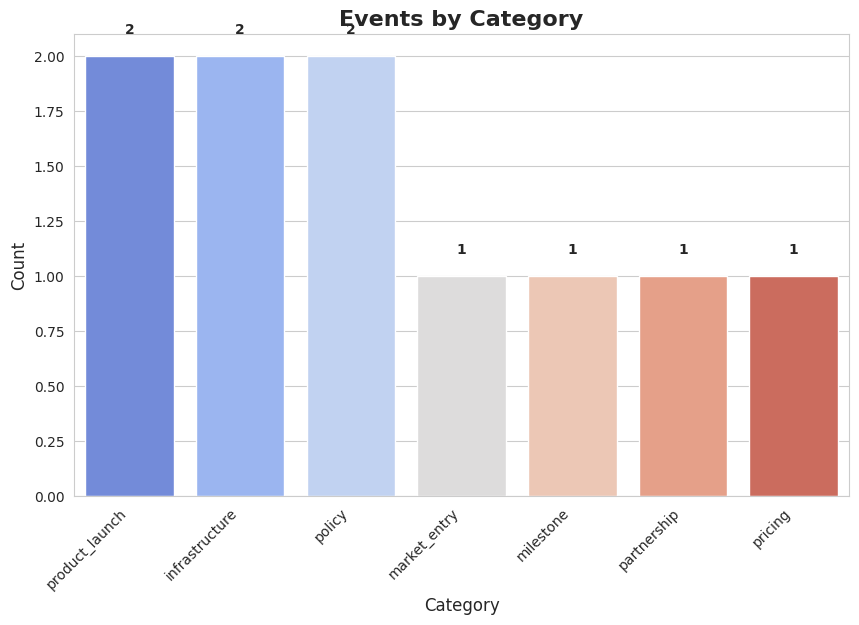

In [11]:
# Event category distribution
event_cat_dist = events['category'].value_counts().reset_index()
event_cat_dist.columns = ['Category', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=event_cat_dist, x='Category', y='Count', palette='coolwarm')
plt.title('Events by Category', fontsize=16, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(event_cat_dist['Count']):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
save_fig('06_events_by_category')
plt.show()

## 7. Impact Links Analysis

In [12]:
# Examine impact links
if len(impact_links) > 0:
    impact_summary = impact_links[[
        'parent_id', 'pillar', 'related_indicator', 
        'impact_direction', 'impact_magnitude', 'lag_months', 'evidence_basis'
    ]].copy()
    
    # Merge with event names
    impact_with_events = impact_summary.merge(
        events[['id', 'event_name']], 
        left_on='parent_id', 
        right_on='id', 
        how='left'
    )
    
    save_summary(impact_with_events, 'impact_links_detailed.csv')
    
    print("Impact Links Summary:")
    print(impact_with_events)
    
    # Impact direction distribution
    impact_dir_dist = impact_links['impact_direction'].value_counts()
    print("\nImpact Direction Distribution:")
    print(impact_dir_dist)

## 8. Data Gaps Identification

In [13]:
# Create comprehensive gap analysis
gaps = []

# Check for indicators with limited temporal coverage
for _, row in indicator_summary.iterrows():
    if row['Count'] < 5:
        gaps.append({
            'Gap Type': 'Limited Observations',
            'Category': row['Pillar'],
            'Indicator': row['Indicator'],
            'Details': f"Only {row['Count']} observations"
        })

# Check for missing years in key indicators
key_years = [2011, 2014, 2017, 2021, 2024]
for year in key_years:
    year_obs = observations[observations['observation_date'].dt.year == year]
    if len(year_obs) == 0:
        gaps.append({
            'Gap Type': 'Missing Year',
            'Category': 'Temporal',
            'Indicator': f'Year {year}',
            'Details': 'No observations for this Findex year'
        })

gaps_df = pd.DataFrame(gaps)
save_summary(gaps_df, 'identified_gaps.csv')

print("\nIdentified Data Gaps:")
print(gaps_df)

✓ Saved: identified_gaps.csv

Identified Data Gaps:
                Gap Type       Category                          Indicator  \
0   Limited Observations         ACCESS        Fayda Digital ID Enrollment   
1   Limited Observations         ACCESS             4G Population Coverage   
2   Limited Observations         ACCESS          Mobile Money Account Rate   
3   Limited Observations         GENDER       Account Ownership Gender Gap   
4   Limited Observations          USAGE              P2P Transaction Count   
5   Limited Observations         ACCESS    Mobile Subscription Penetration   
6   Limited Observations         GENDER  Female Mobile Money Account Share   
7   Limited Observations         GENDER            Mobile Phone Gender Gap   
8   Limited Observations          USAGE              ATM Transaction Count   
9   Limited Observations  AFFORDABILITY           Data Affordability Index   
10  Limited Observations          USAGE              ATM Transaction Value   
11  Limited 

## 9. Data Enrichment Plan

Based on the gaps identified, we will enrich the dataset with:
1. **Additional Observations**: Missing Findex indicators, infrastructure data
2. **Additional Events**: Policy changes, product launches not captured
3. **Additional Impact Links**: New event-indicator relationships

In [14]:
# Create enrichment log structure
enrichment_log = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'observations_original': len(observations),
    'events_original': len(events),
    'impact_links_original': len(impact_links),
    'targets_original': len(targets),
    'gaps_identified': len(gaps_df),
    'enrichment_plan': 'To be executed in subsequent cells'
}

print("\nEnrichment Starting Point:")
for key, value in enrichment_log.items():
    print(f"{key}: {value}")


Enrichment Starting Point:
timestamp: 2026-02-01 12:17:35
observations_original: 30
events_original: 10
impact_links_original: 0
targets_original: 3
gaps_identified: 19
enrichment_plan: To be executed in subsequent cells


## 10. Summary Statistics for Report

In [15]:
# Generate comprehensive summary for report
summary_stats = {
    'Metric': [
        'Total Records',
        'Observations',
        'Events',
        'Impact Links',
        'Targets',
        'Unique Indicators',
        'Temporal Range (Years)',
        'High Confidence Records',
        'Data Gaps Identified'
    ],
    'Value': [
        len(df),
        len(observations),
        len(events),
        len(impact_links),
        len(targets),
        len(indicator_summary),
        f"{observations['observation_date'].dt.year.min()}-{observations['observation_date'].dt.year.max()}",
        len(observations[observations['confidence'] == 'high']),
        len(gaps_df)
    ]
}

summary_df = pd.DataFrame(summary_stats)
save_summary(summary_df, 'exploration_summary_stats.csv')

print("\n" + "="*60)
print("EXPLORATION SUMMARY STATISTICS")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)

✓ Saved: exploration_summary_stats.csv

EXPLORATION SUMMARY STATISTICS
                 Metric     Value
          Total Records        43
           Observations        30
                 Events        10
           Impact Links         0
                Targets         3
      Unique Indicators        19
 Temporal Range (Years) 2014-2025
High Confidence Records        28
   Data Gaps Identified        19
